In [20]:
import sympy as sp
from IPython.display import display, Math, Markdown
from sympy.printing.latex import LatexPrinter

In [21]:
# Main parameters
dx = sp.Symbol('dx', latex=r'\Delta x', positive=True, real=True)
dt = sp.Symbol('dt', latex=r'\Delta t', positive=True, real=True)

a = sp.Symbol('a', positive=True, real=True)
cfl = sp.Symbol('cfl', latex=r'\nu', positive=True, real=True)
sigma = sp.Symbol('sigma', latex=r'\sigma', real=True)

# dx and dt latex symbols (passed in sp.Symbol) seem to be hard-coded to use 
# symbol names, this is a codegen-friendly work-around
symbol_names = {dx: r"\Delta x", dt: r"\Delta t", cfl: r"\nu"}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

In [22]:
# Derivatives
u = sp.Symbol('u')
u_x = sp.Symbol(r"u'_x")
u_xx = sp.Symbol(r"u''_{xx}")
u_xxx = sp.Symbol(r"u'''_{xxx}")
u_xxxx = sp.Symbol(r"u^{(IV)}_{xxxx}")
u_5x = sp.Symbol(r"u^{(V)}_{xxxxx}")
u_6x = sp.Symbol(r"u^{(VI)}_{xxxxxx}")

derivs = [u, u_x, u_xx, u_xxx, u_xxxx, u_5x, u_6x]


def taylor_spatial(offset: int, order: int=6) -> sp.Expr:
    """ Taylor expansion of u(x + offset*dx, t) around (x, t) """
    result: sp.Expr = 0
    for k in range(min(order + 1, len(derivs))):
        result += derivs[k] * (offset * dx)**k / sp.factorial(k)
    return result

In [23]:
# Grid values as symbols (for numerical implementation)
u_im2 = sp.Symbol('u_im2')
u_im1 = sp.Symbol('u_im1')
u_i = sp.Symbol('u_i')
u_ip1 = sp.Symbol('u_ip1')
u_ip2 = sp.Symbol('u_ip2')

# A bit crude
stencil_map = {
    stencil_point: offset for offset, stencil_point in
    enumerate([u_im2, u_im1, u_i, u_ip1, u_ip2], start=-2)
}

# This is just appears to be a better practice with sympy
symbol_names |= {
    u_im2: "u^n_{i - 2}",
    u_im1: "u^n_{i - 1}",
    u_i: "u^n_i",
    u_ip1: "u^n_{i + 1}",
    u_ip2: "u^n_{i + 2}",
}
LatexPrinter.set_global_settings(symbol_names=symbol_names)


def expand_to_taylor(expr: sp.Expr) -> sp.Expr:
    """Replace stencil symbols with Taylor expansions"""
    return sp.simplify(expr.subs(
        {stencil_point: taylor_spatial(offset) for stencil_point, offset in stencil_map.items()}
    ))

In [24]:
# Sanity check
print("Taylor expansions:")
for sym, offset in stencil_map.items():
    if offset != 0:
        display(Math(rf"{symbol_names[sym]} = {sp.latex(taylor_spatial(offset), order='rev-lex')} + \ldots"))

Taylor expansions:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [25]:
u_next = \
    sigma * u_i + (1 - sigma) * (u_ip1 + u_im1) / 2 \
    + -a * dt * (u_ip1 - u_im1) / (2 * dx) \
    + (a * dt)**2 / 2 * (u_ip1 - 2 * u_i + u_im1) / dx**2

# TODO -- this is easily programmable
u_exact = (u
           - a * dt * u_x
           + a**2 * dt**2 / 2 * u_xx
           - a**3 * dt**3 / 6 * u_xxx
           + a**4 * dt**4 / 24 * u_xxxx
           - a**5 * dt**5 / 120 * u_5x
           + a**6 * dt**6 / 720 * u_6x)

display(Math(f"u_i^{{n+1}} = {sp.latex(sp.collect(sp.expand(u_next), [u_im2, u_im1, u_i, u_ip1, u_ip2]))}"))
display(Math(f"u_i^{{n+1}} = {sp.latex(sp.collect(sp.expand(expand_to_taylor(u_next)), derivs))}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [27]:
def get_coeff(expr, deriv):
    return sp.together(sp.simplify(sp.expand(expr).coeff(deriv)))


error = sp.expand(expand_to_taylor(u_next) - u_exact)

error_coeffs = {}

table = \
    r"""
\begin{array} {r r r} \\
& \text{Coefficient} & \text{Error coefficient} \\
\hline \\
"""


for k, deriv in enumerate(derivs):
    error_coeff = get_coeff(error, deriv)
    coeff = get_coeff(expand_to_taylor(u_next), deriv)
    error_coeffs[k] = error_coeff
    table += fr"\dfrac{{\partial^{k} u}}{{\partial x^{k}}} : \
                &\quad {sp.latex(coeff, fold_short_frac=True)} \
                &\quad  {sp.latex(error_coeff, fold_short_frac=True)} \\[1em]"

# error_coeffs[4] +=(a**4 * dt**4 - a**2 * dt**2 * dx**2)
table += r"\end{array}"
display(Math(table))

<IPython.core.display.Math object>

In [28]:
error_coeffs_normalized = [
    sp.simplify(error_coeffs[k] * sp.factorial(k) * 6 / (a**3 * dt**3 * dx**k))
    for k in range(5)]

error_coeffs_normalized = sp.Matrix(error_coeffs_normalized)

# error_coeffs[k] +=(a**4 * dt**4 - a**2 * dt**2 * dx**2)
# error_coeffs_normalized[4] = 0
# error_coeffs_normalized[4] += ((sigma - 1) * dx**4) * 6 /(a**3 * dt**3 * dx**4)
# error_coeffs_normalized = sp.simplify(error_coeffs_normalized)
# error_coeffs_normalized[4] += (a**4 * dt**4 - a**2 * dt**2 * dx**2) * 6 /(a**3 * dt**3 * dx**4)

# pretty printing factoring out of constant
# TODO -- can be factored out into a helper function
display(Math(
        fr"{sp.latex((gcd := sp.gcd(tuple(error_coeffs_normalized))))} \cdot \
              {sp.latex(sp.simplify((error_coeffs_normalized.T / gcd)))}^T"
        ))

<IPython.core.display.Math object>

In [29]:
taylor_coeffs_normalized = sp.Matrix([
    [(-2)**k, (-1)**k, 0**k if k > 0 else 1, 1**k, 2**k]
    for k in range(5)
])

display(Math(
    fr"{sp.latex(taylor_coeffs_normalized)} x = 6 \
        \cdot {sp.latex(error_coeffs_normalized / 6)},\\[2em]"
))

solution = taylor_coeffs_normalized.solve(error_coeffs_normalized)

# pretty printing factoring out of denominator
display(Math(
    fr"x = {sp.latex(1 / (denom_gcd := 4 * dt**3 * dx**4 * a**3))} \
        \cdot {sp.latex(sp.simplify(solution * denom_gcd))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [30]:
A_coef, B_coef, C_coef, D_coef, E_coef = solution

correction_term = -a**3 * dt**3 / 6 * (
    A_coef * u_im2 +
    B_coef * u_im1 +
    C_coef * u_i +
    D_coef * u_ip1 +
    E_coef * u_ip2
)

# Full corrected scheme
u_corrected = u_next + correction_term
u_corrected = sp.expand(u_corrected)

u_corrected

a**4*dt**4*u_i/(4*dx**4) - a**4*dt**4*u_im1/(6*dx**4) + a**4*dt**4*u_im2/(24*dx**4) - a**4*dt**4*u_ip1/(6*dx**4) + a**4*dt**4*u_ip2/(24*dx**4) - a**3*dt**3*u_im1/(6*dx**3) + a**3*dt**3*u_im2/(12*dx**3) + a**3*dt**3*u_ip1/(6*dx**3) - a**3*dt**3*u_ip2/(12*dx**3) - 5*a**2*dt**2*u_i/(4*dx**2) + 2*a**2*dt**2*u_im1/(3*dx**2) - a**2*dt**2*u_im2/(24*dx**2) + 2*a**2*dt**2*u_ip1/(3*dx**2) - a**2*dt**2*u_ip2/(24*dx**2) + 2*a*dt*u_im1/(3*dx) - a*dt*u_im2/(12*dx) - 2*a*dt*u_ip1/(3*dx) + a*dt*u_ip2/(12*dx) + u_i

In [31]:
error_corrected = sp.expand(expand_to_taylor(u_corrected) - u_exact)

for deriv in derivs:
    coeff = sp.simplify(get_coeff(error_corrected, deriv))
    if coeff != 0 or False:
        display(Markdown(
            f"Coefficient of highest-order error term ${sp.latex(deriv)}$: $${sp.latex(coeff)}$$"
        ))
        break

Coefficient of highest-order error term $u^{(V)}_{xxxxx}$: $$\frac{a \Delta t \left(a^{4} \Delta t^{4} - 5 a^{2} \Delta t^{2} \Delta x^{2} + 4 \Delta x^{4}\right)}{120}$$

In [32]:
u_corrected_cfl: sp.Expr = sp.simplify(u_corrected.subs(a*dt, cfl*dx))
assert u_corrected_cfl.coeff(a) == 0 and u_corrected_cfl.coeff(dt) == 0, "Invalid form"

display(Markdown("Complete numerical scheme (CFL form):"))

# display(Math(f"u_i^{{n+1}} = {sp.latex(u_corrected_cfl)}"))

u_corrected_cfl_by_stencil_terms = sp.simplify(
    sp.collect(sp.expand(u_corrected_cfl),
               [u_im2, u_im1, u_i, u_ip1, u_ip2]))

display(Math(f"u_i^{{n+1}} = \
    {sp.latex(u_corrected_cfl_by_stencil_terms, order='grlex')}"))

Complete numerical scheme (CFL form):

<IPython.core.display.Math object>

In [33]:
sp.simplify(u_corrected_cfl.subs({stencil_point: taylor_spatial(offset) for offset, stencil_point in enumerate([u_im2, u_im1, u_i, u_ip1, u_ip2], start=-2)}))

cfl**4*dx**6*u^{(VI)}_{xxxxxx}/144 + cfl**4*dx**4*u^{(IV)}_{xxxx}/24 - cfl**3*dx**5*u^{(V)}_{xxxxx}/24 - cfl**3*dx**3*u'''_{xxx}/6 - cfl**2*dx**6*u^{(VI)}_{xxxxxx}/180 + cfl**2*dx**2*u''_{xx}/2 + cfl*dx**5*u^{(V)}_{xxxxx}/30 - cfl*dx*u'_x + u

In [34]:
def save_to_python_module(expr, filename: str = "mlf_method.py"):
    """Save the complete method as a Python module."""
    
    module_content = f'''
"""
Auto-generated Lax-Friedrichs-type 4th-order scheme for solving the advection equation.
"""

import numpy as np
import numpy.typing as npt

def mlf_step(
    u: npt.NDArray[np.floating],
    dx: np.floating, cfl: np.floating, sigma: np.floating, **_,
) -> npt.NDArray[np.floating]:
    """
    Apply the method using array indexing.
    
    Parameters
    ----------
    u
        Current solution array
    dx
        Spatial step size
    cfl
        CFL number (nu = a*dt/dx)
    sigma
        Dissipation parameter
    
    Returns
    -------
    u_next
        Updated value(s)
    """
    u_new = np.zeros_like(u)
    i = np.arange(2, len(u) - 2)

    u_im2 = u[i-2]
    u_im1 = u[i-1]
    u_i = u[i]
    u_ip1 = u[i+1]
    u_ip2 = u[i+2]
    
    # TODO -- add mypy warning supression
    # pylint: disable=line-too-long
    u_new[i] = {sp.printing.pycode(expr)}
    return u_new
'''
    
    with open(filename, 'w') as file:
        file.write(module_content)
        print(f"Saved method to {filename}")
    

save_to_python_module(u_corrected_cfl, "mlf_method.py")

Saved method to mlf_method.py


# Stability analysis

In [35]:
def compute_stencil_from_scheme():
    """
    Compute stencil coefficients by collecting contributions from each grid point.
    
    For the corrected scheme, we have:
    u_i^{n+1} = s_{-2}*u_{i-2} + s_{-1}*u_{i-1} + s_0*u_i + s_{+1}*u_{i+1} + s_{+2}*u_{i+2}
    
    Returns coefficients in terms of a, dt, dx, sigma.
    """
    
    # Base scheme coefficients (from 3-point stencil)
    # u_next = σ*u_i + (1-σ)/2*(u_{i+1}+u_{i-1}) - a*dt/(2dx)*(u_{i+1}-u_{i-1}) 
    #        + (a*dt)²/(2dx²)*(u_{i+1} - 2u_i + u_{i-1})
    
    s_base = {
        -1: (1-sigma)/2 + a*dt/(2*dx) + (a*dt)**2/(2*dx**2),
         0: sigma - (a*dt)**2/dx**2,
        +1: (1-sigma)/2 - a*dt/(2*dx) + (a*dt)**2/(2*dx**2),
    }
    
    # Correction coefficients: -a³dt³/6 * [A, B, C, D, E]
    s_corr = {
        -2: -a**3*dt**3/6 * A_coef,
        -1: -a**3*dt**3/6 * B_coef,
         0: -a**3*dt**3/6 * C_coef,
        +1: -a**3*dt**3/6 * D_coef,
        +2: -a**3*dt**3/6 * E_coef,
    }
    
    # Combined stencil
    stencil = {}
    for m in [-2, -1, 0, +1, +2]:
        stencil[m] = sp.simplify(s_base.get(m, 0) + s_corr.get(m, 0))
    
    return stencil

stencil = compute_stencil_from_scheme()

print("Stencil coefficients s_m (u_i^{n+1} = Σ s_m * u_{i+m}):")
print("="*60)
for m in [-2, -1, 0, +1, +2]:
    display(Math(f"s_{{{m:+d}}} = {sp.latex(stencil[m])}"))

Stencil coefficients s_m (u_i^{n+1} = Σ s_m * u_{i+m}):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [36]:


def convert_to_cfl(expr):
    """Replace a*dt/dx with cfl (nu)."""
    return sp.simplify(expr.subs(a*dt, cfl*dx))

stencil_cfl = {m: convert_to_cfl(s) for m, s in stencil.items()}

print("Stencil coefficients in CFL form (ν = a·Δt/Δx):")
print("="*60)
for m in [-2, -1, 0, +1, +2]:
    display(Math(f"s_{{{m:+d}}} = {sp.latex(stencil_cfl[m])}"))

# Verify: coefficients should sum to 1 (conservation)
total = sum(stencil_cfl.values())
total_simplified = sp.simplify(total)
print(f"\nSum of coefficients: {total_simplified}")
assert total_simplified == 1, "Coefficients don't sum to 1!"
print("✓ Conservation verified (sum = 1)")

Stencil coefficients in CFL form (ν = a·Δt/Δx):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Sum of coefficients: 1
✓ Conservation verified (sum = 1)


In [37]:
from sympy import exp, I, cos, sin, re, im, trigsimp, factor, Abs

theta = sp.Symbol('theta', real=True)

In [38]:
def compute_amplification_factor(stencil_cfl):
    """
    Compute the amplification factor G(θ) for von Neumann analysis.
    
    For a 5-point stencil: G = Σ s_m * exp(i*m*θ)
    where θ = k*Δx is the dimensionless wavenumber.
    """
    G = sp.Integer(0)
    for m, coeff in stencil_cfl.items():
        G += coeff * exp(I * m * theta)
    
    return G

G = compute_amplification_factor(stencil_cfl)
G_simplified = sp.simplify(G)

print("Amplification factor G(θ):")
display(Math(f"G(\\theta) = {sp.latex(G_simplified)}"))

Amplification factor G(θ):


<IPython.core.display.Math object>

In [39]:
def analyze_amplification_factor(G_expr):
    """Separate G into real and imaginary parts using Euler's formula."""
    
    # Expand using exp(imθ) = cos(mθ) + i*sin(mθ)
    G_expanded = G_expr.rewrite(cos, sin)
    G_expanded = sp.expand(G_expanded)
    
    # Separate real and imaginary parts
    G_real = sp.simplify(re(G_expanded))
    G_imag = sp.simplify(im(G_expanded))
    
    # |G|² = Re(G)² + Im(G)²
    G_mod_sq = sp.simplify(G_real**2 + G_imag**2)
    
    return G_real, G_imag, G_mod_sq

G_real, G_imag, G_mod_sq = analyze_amplification_factor(G)

print("Real part of G:")
G_real_trig = trigsimp(G_real)
display(Math(f"\\Re(G) = {sp.latex(G_real_trig)}"))

print("\nImaginary part of G:")
G_imag_trig = trigsimp(G_imag)
display(Math(f"\\Im(G) = {sp.latex(G_imag_trig)}"))

print("\n|G|²:")
G_mod_sq_trig = trigsimp(G_mod_sq)
display(Math(f"|G|^2 = {sp.latex(G_mod_sq_trig)}"))

Real part of G:


<IPython.core.display.Math object>


Imaginary part of G:


<IPython.core.display.Math object>


|G|²:


<IPython.core.display.Math object>

In [40]:
def express_in_cosines(G_expr):
    """
    Express G in terms of cos(θ), cos(2θ), sin(θ), sin(2θ).
    
    Using: exp(±imθ) = cos(mθ) ± i*sin(mθ)
    """
    # Substitution rules
    G_trig = G_expr.rewrite(cos, sin)
    G_trig = sp.expand(G_trig)
    
    # Collect by trigonometric functions
    c1 = cos(theta)
    c2 = cos(2*theta)
    s1 = sin(theta)
    s2 = sin(2*theta)
    
    return trigsimp(G_trig)

G_trig = express_in_cosines(G)
print("G in trigonometric form:")
display(Math(f"G(\\theta) = {sp.latex(G_trig)}"))

# Collect real and imaginary parts more explicitly
G_real_explicit = trigsimp(sp.re(G_trig.rewrite(exp)).rewrite(cos, sin))
G_imag_explicit = trigsimp(sp.im(G_trig.rewrite(exp)).rewrite(cos, sin))

print("\nExplicit forms:")
display(Math(f"\\Re(G) = {sp.latex(G_real_explicit)}"))
display(Math(f"\\Im(G) = {sp.latex(G_imag_explicit)}"))

G in trigonometric form:


<IPython.core.display.Math object>


Explicit forms:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [41]:
def stability_analysis(G_mod_sq_expr):
    """
    Analyze stability condition |G|² ≤ 1.
    
    We need |G|² - 1 ≤ 0 for all θ ∈ [0, 2π].
    """
    
    stability_expr = G_mod_sq_expr - 1
    stability_simplified = trigsimp(sp.expand(stability_expr))
    
    return stability_simplified

stability_condition = stability_analysis(G_mod_sq)

print("Stability condition (|G|² - 1 ≤ 0):")
display(Math(f"|G|^2 - 1 = {sp.latex(trigsimp(stability_condition))}"))

# Try to factor or sp.simplify further
try:
    stability_factored = factor(stability_condition)
    print("\nFactored form:")
    display(Math(f"|G|^2 - 1 = {sp.latex(stability_factored)}"))
except:
    pass

Stability condition (|G|² - 1 ≤ 0):


<IPython.core.display.Math object>


Factored form:


<IPython.core.display.Math object>

In [42]:
def check_special_cases():
    """Verify stability at critical wavenumbers."""
    
    special_thetas = {
        '0': 0,
        'π/2': sp.pi/2,
        'π': sp.pi,
        '3π/2': 3*sp.pi/2,
    }
    
    print("Amplification factor at special wavenumbers:")
    print("="*60)
    
    results = {}
    for name, theta_val in special_thetas.items():
        G_val = G.subs(theta, theta_val)
        G_val_simplified = sp.simplify(G_val)
        G_mod = sp.simplify(Abs(G_val_simplified))
        
        results[name] = {'G': G_val_simplified, '|G|': G_mod}
        
        display(Math(f"\\theta = {name}: \\quad G = {sp.latex(G_val_simplified)}, \\quad |G| = {sp.latex(G_mod)}"))
    
    return results

special_cases = check_special_cases()

Amplification factor at special wavenumbers:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [43]:
def extract_stencil_coefficients(scheme_expr, stencil_points):
    """
    Extract the coefficient of each u_{i+m} from the scheme.
    
    Returns dict: {offset: coefficient} where offset is the stencil position.
    """
    # We need to collect coefficients of u_i, u_{i±1}, u_{i±2}
    # These appear as combinations of u and its derivatives
    
    # Strategy: substitute specific values for derivatives to isolate contributions
    # from each stencil point
    
    # Alternative: work directly with the unexpanded form
    # For 5-point stencil, coefficients come from combining:
    # 1. Base scheme (3-point)
    # 2. Correction term (5-point)
    
    return None  # We'll use a different approach below

def compute_stencil_from_scheme():
    """
    Compute stencil coefficients by collecting contributions from each grid point.
    
    For the corrected scheme, we have:
    u_i^{n+1} = s_{-2}*u_{i-2} + s_{-1}*u_{i-1} + s_0*u_i + s_{+1}*u_{i+1} + s_{+2}*u_{i+2}
    
    Returns coefficients in terms of a, dt, dx, sigma.
    """
    
    # Base scheme coefficients (from 3-point stencil)
    # u_next = σ*u_i + (1-σ)/2*(u_{i+1}+u_{i-1}) - a*dt/(2dx)*(u_{i+1}-u_{i-1}) 
    #        + (a*dt)²/(2dx²)*(u_{i+1} - 2u_i + u_{i-1})
    
    s_base = {
        -1: (1-sigma)/2 + a*dt/(2*dx) + (a*dt)**2/(2*dx**2),
         0: sigma - (a*dt)**2/dx**2,
        +1: (1-sigma)/2 - a*dt/(2*dx) + (a*dt)**2/(2*dx**2),
    }
    
    # Correction coefficients: -a³dt³/6 * [A, B, C, D, E]
    s_corr = {
        -2: -a**3*dt**3/6 * A_coef,
        -1: -a**3*dt**3/6 * B_coef,
         0: -a**3*dt**3/6 * C_coef,
        +1: -a**3*dt**3/6 * D_coef,
        +2: -a**3*dt**3/6 * E_coef,
    }
    
    # Combined stencil
    stencil = {}
    for m in [-2, -1, 0, +1, +2]:
        stencil[m] = sp.simplify(s_base.get(m, 0) + s_corr.get(m, 0))
    
    return stencil

stencil = compute_stencil_from_scheme()

print("Stencil coefficients s_m (u_i^{n+1} = Σ s_m * u_{i+m}):")
print("="*60)
for m in [-2, -1, 0, +1, +2]:
    display(Math(f"s_{{{m:+d}}} = {sp.latex(stencil[m])}"))

Stencil coefficients s_m (u_i^{n+1} = Σ s_m * u_{i+m}):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [44]:
def extract_stencil_coefficients(scheme_expr, stencil_points):
    """
    Extract the coefficient of each u_{i+m} from the scheme.
    
    Returns dict: {offset: coefficient} where offset is the stencil position.
    """
    # We need to collect coefficients of u_i, u_{i±1}, u_{i±2}
    # These appear as combinations of u and its derivatives
    
    # Strategy: substitute specific values for derivatives to isolate contributions
    # from each stencil point
    
    # Alternative: work directly with the unexpanded form
    # For 5-point stencil, coefficients come from combining:
    # 1. Base scheme (3-point)
    # 2. Correction term (5-point)
    
    return None  # We'll use a different approach below

def compute_stencil_from_scheme():
    """
    Compute stencil coefficients by collecting contributions from each grid point.
    
    For the corrected scheme, we have:
    u_i^{n+1} = s_{-2}*u_{i-2} + s_{-1}*u_{i-1} + s_0*u_i + s_{+1}*u_{i+1} + s_{+2}*u_{i+2}
    
    Returns coefficients in terms of a, dt, dx, sigma.
    """
    
    # Base scheme coefficients (from 3-point stencil)
    # u_next = σ*u_i + (1-σ)/2*(u_{i+1}+u_{i-1}) - a*dt/(2dx)*(u_{i+1}-u_{i-1}) 
    #        + (a*dt)²/(2dx²)*(u_{i+1} - 2u_i + u_{i-1})
    
    s_base = {
        -1: (1-sigma)/2 + a*dt/(2*dx) + (a*dt)**2/(2*dx**2),
         0: sigma - (a*dt)**2/dx**2,
        +1: (1-sigma)/2 - a*dt/(2*dx) + (a*dt)**2/(2*dx**2),
    }
    
    # Correction coefficients: -a³dt³/6 * [A, B, C, D, E]
    s_corr = {
        -2: -a**3*dt**3/6 * A_coef,
        -1: -a**3*dt**3/6 * B_coef,
         0: -a**3*dt**3/6 * C_coef,
        +1: -a**3*dt**3/6 * D_coef,
        +2: -a**3*dt**3/6 * E_coef,
    }
    
    # Combined stencil
    stencil = {}
    for m in [-2, -1, 0, +1, +2]:
        stencil[m] = sp.simplify(s_base.get(m, 0) + s_corr.get(m, 0))
    
    return stencil

stencil = compute_stencil_from_scheme()

print("Stencil coefficients s_m (u_i^{n+1} = Σ s_m * u_{i+m}):")
print("="*60)
for m in [-2, -1, 0, +1, +2]:
    display(Math(f"s_{{{m:+d}}} = {sp.latex(stencil[m])}"))

Stencil coefficients s_m (u_i^{n+1} = Σ s_m * u_{i+m}):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [45]:
def stability_analysis(G_mod_sq_expr):
    """
    Analyze stability condition |G|² ≤ 1.
    
    We need |G|² - 1 ≤ 0 for all θ ∈ [0, 2π].
    """
    
    stability_expr = G_mod_sq_expr - 1
    stability_simplified = trigsimp(sp.expand(stability_expr))
    
    return stability_simplified

stability_condition = stability_analysis(G_mod_sq)

print("Stability condition (|G|² - 1 ≤ 0):")
display(Math(f"|G|^2 - 1 = {sp.latex(trigsimp(stability_condition))}"))

# Try to factor or sp.simplify further
try:
    stability_factored = factor(stability_condition)
    print("\nFactored form:")
    display(Math(f"|G|^2 - 1 = {sp.latex(stability_factored)}"))
except:
    pass

Stability condition (|G|² - 1 ≤ 0):


<IPython.core.display.Math object>


Factored form:


<IPython.core.display.Math object>

In [46]:
def check_special_cases():
    """Verify stability at critical wavenumbers."""
    
    special_thetas = {
        '0': 0,
        'π/2': sp.pi/2,
        'π': sp.pi,
        '3π/2': 3*sp.pi/2,
    }
    
    print("Amplification factor at special wavenumbers:")
    print("="*60)
    
    results = {}
    for name, theta_val in special_thetas.items():
        G_val = G.subs(theta, theta_val)
        G_val_simplified = sp.simplify(G_val)
        G_mod = sp.simplify(Abs(G_val_simplified))
        
        results[name] = {'G': G_val_simplified, '|G|': G_mod}
        
        display(Math(f"\\theta = {name}: \\quad G = {sp.latex(G_val_simplified)}, \\quad |G| = {sp.latex(G_mod)}"))
    
    return results

special_cases = check_special_cases()

Amplification factor at special wavenumbers:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [47]:
print("Special case: σ = 1 (Lax-Wendroff scheme)")
print("="*60)

G_lw = G.subs(sigma, 1)
G_lw_simplified = trigsimp(sp.simplify(G_lw))

print("Amplification factor:")
display(Math(f"G_{{LW}}(\\theta) = {sp.latex(G_lw_simplified)}"))

G_lw_real = trigsimp(sp.simplify(re(G_lw_simplified.rewrite(cos, sin))))
G_lw_imag = trigsimp(sp.simplify(im(G_lw_simplified.rewrite(cos, sin))))

print("\nComponents:")
display(Math(f"\\Re(G_{{LW}}) = {sp.latex(G_lw_real)}"))
display(Math(f"\\Im(G_{{LW}}) = {sp.latex(G_lw_imag)}"))

G_lw_mod_sq = trigsimp(sp.simplify(G_lw_real**2 + G_lw_imag**2))
print("\n|G|²:")
display(Math(f"|G_{{LW}}|^2 = {sp.latex(G_lw_mod_sq)}"))

Special case: σ = 1 (Lax-Wendroff scheme)
Amplification factor:


<IPython.core.display.Math object>


Components:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


|G|²:


<IPython.core.display.Math object>

In [48]:
print("Special case: σ = 0 (Maximum averaging)")
print("="*60)

G_lf = G.subs(sigma, 0)
G_lf_simplified = trigsimp(sp.simplify(G_lf))

print("Amplification factor:")
display(Math(f"G_{{\\sigma=0}}(\\theta) = {sp.latex(G_lf_simplified)}"))

G_lf_mod_sq = trigsimp(sp.simplify(Abs(G_lf_simplified)**2))
G_lf_mod_sq = G_lf_mod_sq.rewrite(cos, sin)
G_lf_mod_sq = trigsimp(sp.expand(G_lf_mod_sq))

print("\n|G|²:")
display(Math(f"|G_{{\\sigma=0}}|^2 = {sp.latex(G_lf_mod_sq)}"))

Special case: σ = 0 (Maximum averaging)
Amplification factor:


<IPython.core.display.Math object>


|G|²:


<IPython.core.display.Math object>

In [49]:
def find_stability_bounds():
    """
    Find constraints on ν (CFL) for stability.
    
    We need |G|² ≤ 1 for all θ. 
    The worst case is typically at θ = π (highest frequency).
    """
    
    print("Stability analysis at θ = π (worst case for many schemes):")
    print("="*60)
    
    G_at_pi = G.subs(theta, sp.pi)
    G_at_pi_simplified = sp.simplify(G_at_pi)
    
    display(Math(f"G(\\pi) = {sp.latex(G_at_pi_simplified)}"))
    
    # |G(π)|² 
    G_mod_sq_pi = sp.simplify(Abs(G_at_pi_simplified)**2)
    # For real G, |G|² = G²
    G_mod_sq_pi = sp.simplify(G_at_pi_simplified**2)
    
    display(Math(f"|G(\\pi)|^2 = {sp.latex(G_mod_sq_pi)}"))
    
    # Stability: |G(π)|² ≤ 1
    stability_ineq = G_mod_sq_pi - 1
    stability_ineq_simplified = sp.simplify(stability_ineq)
    
    print("\nCondition |G(π)|² - 1 ≤ 0:")
    display(Math(f"{sp.latex(stability_ineq_simplified)} \\leq 0"))
    
    # Solve |G|² = 1 for critical CFL
    try:
        critical_cfl = sp.solve(stability_ineq_simplified, cfl)
        print("\nCritical CFL values (where |G| = 1):")
        for sol in critical_cfl:
            display(Math(f"\\nu = {sp.latex(sp.simplify(sol))}"))
    except Exception as e:
        print(f"Could not solve analytically: {e}")
    
    return G_at_pi_simplified, stability_ineq_simplified

G_pi, stability_pi = find_stability_bounds()

Stability analysis at θ = π (worst case for many schemes):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Condition |G(π)|² - 1 ≤ 0:


<IPython.core.display.Math object>


Critical CFL values (where |G| = 1):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

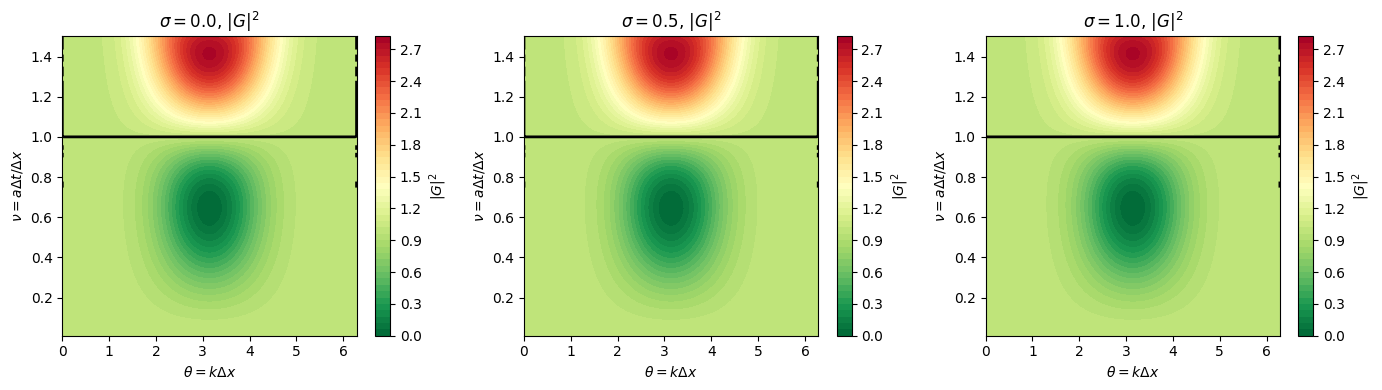


Maximum stable CFL (where |G|² ≤ 1 for all θ):
  σ = 0.0: ν_max ≈ 0.9967
  σ = 0.5: ν_max ≈ 0.9967
  σ = 1.0: ν_max ≈ 0.9967


In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stability_region():
    """Numerically compute and plot |G|² for various CFL and θ."""
    
    # Lambdify for numerical evaluation
    G_numeric = sp.lambdify((theta, cfl, sigma), G, modules='numpy')
    
    theta_vals = np.linspace(0, 2*np.pi, 200)
    cfl_vals = np.linspace(0.01, 1.5, 100)
    sigma_vals = [0.0, 0.5, 1.0]
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    for ax, sig in zip(axes, sigma_vals):
        # Compute |G|² for each (θ, ν) pair
        THETA, CFL = np.meshgrid(theta_vals, cfl_vals)
        G_vals = G_numeric(THETA, CFL, sig)
        G_mod_sq_vals = np.abs(G_vals)**2
        
        # Plot
        contour = ax.contourf(THETA, CFL, G_mod_sq_vals, levels=50, cmap='RdYlGn_r')
        ax.contour(THETA, CFL, G_mod_sq_vals, levels=[1.0], colors='black', linewidths=2)
        
        ax.set_xlabel(r'$\theta = k \Delta x$')
        ax.set_ylabel(r'$\nu = a \Delta t / \Delta x$')
        ax.set_title(f'$\\sigma = {sig}$, $|G|^2$')
        
        plt.colorbar(contour, ax=ax, label=r'$|G|^2$')
    
    plt.tight_layout()
    plt.savefig('stability_region.png', dpi=150)
    plt.show()
    
    # Find maximum stable CFL for each sigma
    print("\nMaximum stable CFL (where |G|² ≤ 1 for all θ):")
    for sig in sigma_vals:
        for nu_test in np.linspace(1.5, 0.01, 300):
            G_vals = G_numeric(theta_vals, nu_test, sig)
            if np.all(np.abs(G_vals)**2 <= 1.0 + 1e-10):
                print(f"  σ = {sig}: ν_max ≈ {nu_test:.4f}")
                break

plot_stability_region()

In [51]:
def dissipation_dispersion_analysis():
    """
    Analyze numerical dissipation and dispersion.
    
    For the exact solution: u(x,t) ∝ exp(i(kx - ωt)) with ω = ak (non-dispersive)
    
    Numerical scheme: G = |G| * exp(-i*φ) where
    - |G| < 1 → dissipation (amplitude decay)
    - φ ≠ ν*θ → dispersion (phase error)
    """
    
    print("Dissipation and Dispersion Analysis:")
    print("="*60)
    
    # For exact advection: G_exact = exp(-i*ν*θ)
    G_exact = exp(-I * cfl * theta)
    
    # Numerical phase: φ = -arg(G)
    # Numerical amplitude: |G|
    
    G_trig = G.rewrite(cos, sin)
    G_real_part = trigsimp(re(G_trig))
    G_imag_part = trigsimp(im(G_trig))
    
    print("For phase/dissipation analysis:")
    print("G = |G| * exp(-i*φ_num)")
    print("\nwhere:")
    display(Math(f"|G| = \\sqrt{{(\\Re G)^2 + (\\Im G)^2}}"))
    display(Math(f"\\phi_{{num}} = -\\arctan\\left(\\frac{{\\Im G}}{{\\Re G}}\\right)"))
    
    print("\nExact phase advance per time step:")
    display(Math(f"\\phi_{{exact}} = \\nu \\theta"))
    
    print("\nPhase error (dispersion):")
    display(Math(f"\\epsilon_\\phi = \\phi_{{num}} - \\phi_{{exact}}"))
    
    print("\nDissipation (amplitude ratio per step):")
    display(Math(f"|G| \\text{{ should be }} 1 \\text{{ for no dissipation}}"))
    
    return G_real_part, G_imag_part

G_re, G_im = dissipation_dispersion_analysis()

Dissipation and Dispersion Analysis:
For phase/dissipation analysis:
G = |G| * exp(-i*φ_num)

where:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Exact phase advance per time step:


<IPython.core.display.Math object>


Phase error (dispersion):


<IPython.core.display.Math object>


Dissipation (amplitude ratio per step):


<IPython.core.display.Math object>

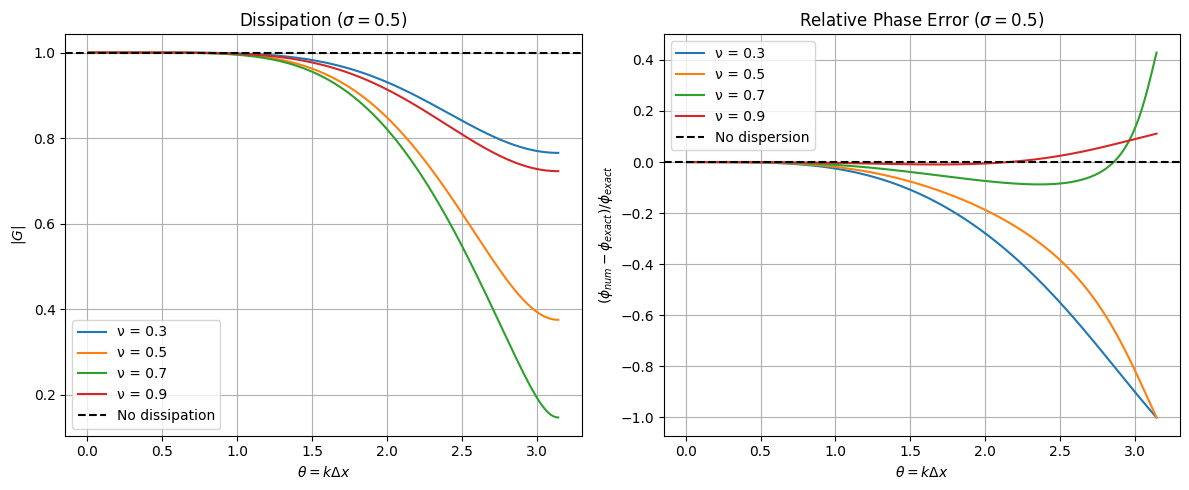

In [52]:
def plot_dissipation_dispersion():
    """Plot |G| and phase error vs θ for various CFL values."""
    
    G_numeric = sp.lambdify((theta, cfl, sigma), G, modules='numpy')
    
    theta_vals = np.linspace(0.01, np.pi, 200)
    cfl_vals = [0.3, 0.5, 0.7, 0.9]
    sig = 0.5  # Example sigma
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Dissipation: |G|
    ax1 = axes[0]
    for nu in cfl_vals:
        G_vals = G_numeric(theta_vals, nu, sig)
        ax1.plot(theta_vals, np.abs(G_vals), label=f'ν = {nu}')
    ax1.axhline(y=1, color='k', linestyle='--', label='No dissipation')
    ax1.set_xlabel(r'$\theta = k \Delta x$')
    ax1.set_ylabel(r'$|G|$')
    ax1.set_title(f'Dissipation ($\\sigma = {sig}$)')
    ax1.legend()
    ax1.grid(True)
    
    # Dispersion: phase error
    ax2 = axes[1]
    for nu in cfl_vals:
        G_vals = G_numeric(theta_vals, nu, sig)
        phi_num = -np.angle(G_vals)
        phi_exact = nu * theta_vals
        # Normalize by exact phase for relative error
        phase_error = (phi_num - phi_exact) / (phi_exact + 1e-10)
        ax2.plot(theta_vals, phase_error, label=f'ν = {nu}')
    ax2.axhline(y=0, color='k', linestyle='--', label='No dispersion')
    ax2.set_xlabel(r'$\theta = k \Delta x$')
    ax2.set_ylabel(r'$(\phi_{num} - \phi_{exact}) / \phi_{exact}$')
    ax2.set_title(f'Relative Phase Error ($\\sigma = {sig}$)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('dissipation_dispersion.png', dpi=150)
    plt.show()

plot_dissipation_dispersion()